In [1]:
import pandas as pd 
import pandas_ta as ta

In [51]:
asset = 'mog-coin'
volume_data = pd.read_csv(f'/Users/valter.rebelo/MissionControl/data/micro/assetData/{asset}.csv')[['date', 'total_volume']]
volume_data.set_index('date', inplace=True)
volume_data.dropna(inplace=True)
data = pd.read_csv(f'/Users/valter.rebelo/MissionControl/data/micro/candleData/{asset}_candles.csv')
data.set_index('date', inplace=True)
data.dropna(inplace=True)
data = data.join(volume_data, how='left')
data
data = data.loc['2021-01-01':'2025-10-16']

# Calculate rolling z-score normalized OHLC data with 14-day window
rolling_mean_close = data['close'].rolling(window=20).mean()
rolling_std_close = data['close'].rolling(window=20).std()
data['z_close'] = (data['close'] - rolling_mean_close) / rolling_std_close

rolling_mean_open = data['open'].rolling(window=20).mean()
rolling_std_open = data['open'].rolling(window=20).std()
data['z_open'] = (data['open'] - rolling_mean_open) / rolling_std_open

rolling_mean_high = data['high'].rolling(window=20).mean()
rolling_std_high = data['high'].rolling(window=20).std()
data['z_high'] = (data['high'] - rolling_mean_high) / rolling_std_high

rolling_mean_low = data['low'].rolling(window=20).mean()  
rolling_std_low = data['low'].rolling(window=20).std()
data['z_low'] = (data['low'] - rolling_mean_low) / rolling_std_low

# Calculate the mean of normalized OHLC
data['z_ohlc_mean'] = (data['z_open'] + data['z_high'] + data['z_low'] + data['z_close']) / 4

# Calculate RSI on normalized OHLC data
data['rsi_z_close'] = ta.rsi(data['z_close'], length=28)
data['rsi_z_high'] = ta.rsi(data['z_high'], length=28)
data['rsi_z_low'] = ta.rsi(data['z_low'], length=28)
data['rsi_z_open'] = ta.rsi(data['z_open'], length=28)
# Calculate the average of the four normalized RSI values
data['rsi_z_smooth'] = (data['rsi_z_close'] + data['rsi_z_high'] + data['rsi_z_low'] + data['rsi_z_open']) / 4

# Calculate ROC on normalized OHLC data
data['z_close_roc'] = ta.roc(data['z_close'], length=28)
data['z_high_roc'] = ta.roc(data['z_high'], length=28)
data['z_low_roc'] = ta.roc(data['z_low'], length=28)
data['z_open_roc'] = ta.roc(data['z_open'], length=28)
data['z_smooth_roc'] = (data['z_close_roc'] + data['z_high_roc'] + data['z_low_roc'] + data['z_open_roc']) / 4

# Create RSI momentum indicator based on normalized data
data['rsi_z_momentum'] = 0  # Initialize with default value of 0

# Initialize a variable to track the last active mode
last_active_mode = 0

# Process each row to determine rsi_z_momentum with memory of last active mode
for idx in data.index:
    # Bullish condition: RSI smooth > 50 AND smooth ROC > 0
    if data.loc[idx, 'rsi_z_smooth'] > 50 and data.loc[idx, 'z_smooth_roc'] > 0:
        data.loc[idx, 'rsi_z_momentum'] = 1
        last_active_mode = 1
    # Bearish condition: RSI smooth < 50 AND smooth ROC < 0
    elif data.loc[idx, 'rsi_z_smooth'] < 50 and data.loc[idx, 'z_smooth_roc'] < 0:
        data.loc[idx, 'rsi_z_momentum'] = 0
        last_active_mode = 0
    # Mixed conditions: keep the last active mode
    else:
        data.loc[idx, 'rsi_z_momentum'] = last_active_mode

# Also keep the original RSI signal for comparison
# Fix the RSI calculation - correct syntax for pandas_ta.rsi
data['rsi_close'] = ta.rsi(data['close'], length=28)
data['rsi_high'] = ta.rsi(data['high'], length=28)
data['rsi_low'] = ta.rsi(data['low'], length=28)
data['rsi_open'] = ta.rsi(data['open'], length=28)
# Calculate the average of the four RSI values
data['rsi_smooth'] = (data['rsi_close'] + data['rsi_high'] + data['rsi_low'] + data['rsi_open']) / 4

data['close_roc'] = ta.roc(data['close'], length=28)  # Using ta.roc instead of pct_change
data['high_roc'] = ta.roc(data['high'], length=28)
data['low_roc'] = ta.roc(data['low'], length=28)
data['open_roc'] = ta.roc(data['open'], length=28)
data['smooth_roc'] = (data['close_roc'] + data['high_roc'] + data['low_roc'] + data['open_roc']) / 4

# Create original RSI momentum indicator for comparison
data['rsi_momentum'] = 0  # Initialize with default value of 0

# Initialize a variable to track the last active mode
last_active_mode_orig = 0

# Process each row to determine rsi_momentum with memory of last active mode
for idx in data.index:
    # Bullish condition: RSI smooth > 50 AND smooth ROC > 0
    if data.loc[idx, 'rsi_smooth'] > 50 and data.loc[idx, 'smooth_roc'] > 0:
        data.loc[idx, 'rsi_momentum'] = 1
        last_active_mode_orig = 1
    # Bearish condition: RSI smooth < 50 AND smooth ROC < 0
    elif data.loc[idx, 'rsi_smooth'] < 50 and data.loc[idx, 'smooth_roc'] < 0:
        data.loc[idx, 'rsi_momentum'] = 0
        last_active_mode_orig = 0
    # Mixed conditions: keep the last active mode
    else:
        data.loc[idx, 'rsi_momentum'] = last_active_mode_orig

# Calculate forward returns
data['forward_5d_returns'] = data['close'].pct_change(periods=5).shift(-5)
data['forward_10d_returns'] = data['close'].pct_change(periods=10).shift(-10)
data['forward_20d_returns'] = data['close'].pct_change(periods=20).shift(-20)  # Assuming 21 trading days in a month

# Calculate rolling z-score normalized close with 20-day window
rolling_mean = data['close'].rolling(window=20).mean()
rolling_std = data['close'].rolling(window=20).std()
data['z'] = (data['close'] - rolling_mean) / rolling_std

rolling_mean_vol = data['total_volume'].rolling(window=20).mean()
rolling_std_vol = data['total_volume'].rolling(window=20).std()
data['z_vol'] = (data['total_volume'] - rolling_mean_vol) / rolling_std_vol

data['ohlc_mean'] = (data['open'] + data['high'] + data['low'] + data['close']) / 4

# Calculate rolling z-score for the OHLC mean with 20-day window
ohlc_rolling_mean = data['ohlc_mean'].rolling(window=20).mean()
ohlc_rolling_std = data['ohlc_mean'].rolling(window=20).std()
data['z_ohlc'] = (data['ohlc_mean'] - ohlc_rolling_mean) / ohlc_rolling_std

# Drop NaN values
data.dropna(inplace=True)


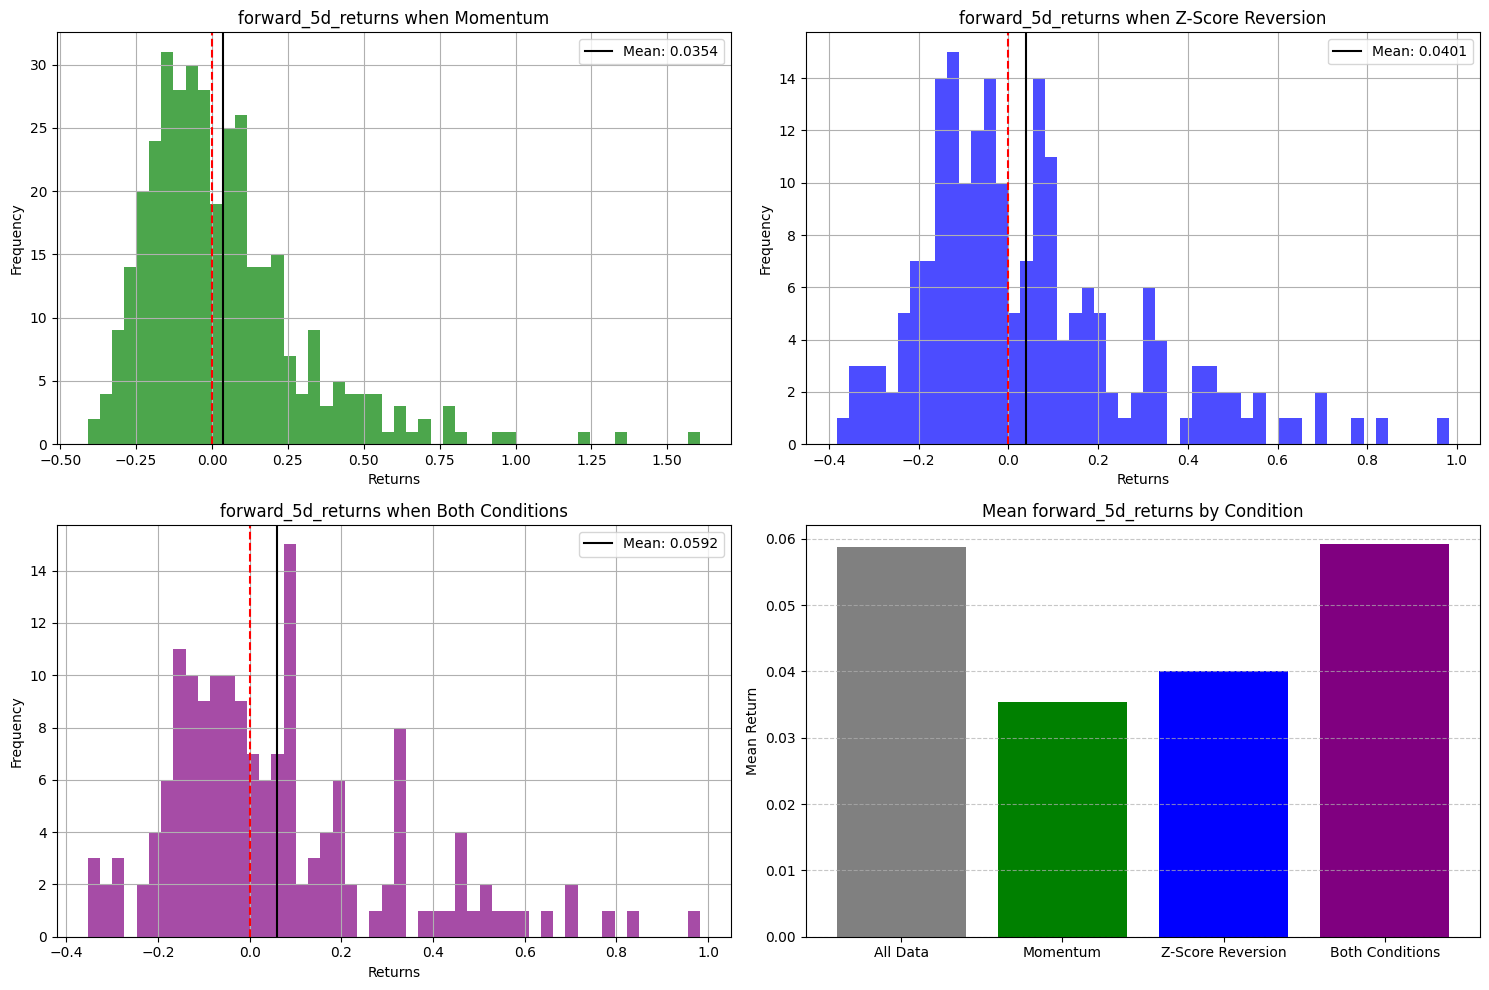


Summary Statistics for forward_5d_returns:
Condition                  Mean     Median        Min        Max       Skew   Kurtosis  Risk/Reward  Q10/Q90 R/R        Q10        Q90      Count
-------------------- ---------- ---------- ---------- ---------- ---------- ---------- ------------ ------------ ---------- ---------- ----------
All data                 0.0588    -0.0136    -0.4299     2.9128     2.7360    13.5000         6.86         1.85    -0.2273     0.4260        752
Momentum                 0.0354    -0.0174    -0.4100     1.6087     1.8249     5.6465         3.92         1.57    -0.2269     0.3564        359
Z-Score Reversion        0.0401    -0.0127    -0.3829     0.9831     1.1388     1.4628         2.57         1.87    -0.2092     0.3905        199
Both Conditions          0.0592    -0.0034    -0.3540     0.9831     1.1554     1.3854         2.78         2.39    -0.1819     0.4339        161


In [52]:
import matplotlib.pyplot as plt

# Create a figure with subplots for different conditions
plt.figure(figsize=(15, 10))

# Define the return column to analyze
return_column = 'forward_5d_returns'

# Define conditions with descriptive names
condition1_name = 'Momentum'
condition2_name = 'Z-Score Reversion'
combined_name = 'Both Conditions'

# Define the actual conditions
conditions = {
    condition1_name: data['rsi_momentum'] == 0,
    condition2_name:  (data['z_ohlc'] >= -2) & (data['z_ohlc'] <= -1),
    combined_name: (data['rsi_momentum'] == 0) & (data['z_ohlc'] >= -2) & (data['z_ohlc'] <= -1)
    }#

# Plot 1: Forward returns for condition 1
plt.subplot(2, 2, 1)
data[conditions[condition1_name]][return_column].hist(bins=50, alpha=0.7, color='green')
plt.title(f'{return_column} when {condition1_name}')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=data[conditions[condition1_name]][return_column].mean(), 
           color='black', linestyle='-', label=f"Mean: {data[conditions[condition1_name]][return_column].mean():.4f}")
plt.legend()

# Plot 2: Forward returns for condition 2
plt.subplot(2, 2, 2)
data[conditions[condition2_name]][return_column].hist(bins=50, alpha=0.7, color='blue')
plt.title(f'{return_column} when {condition2_name}')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=data[conditions[condition2_name]][return_column].mean(), 
           color='black', linestyle='-', label=f"Mean: {data[conditions[condition2_name]][return_column].mean():.4f}")
plt.legend()

# Plot 3: Forward returns when both conditions are met
plt.subplot(2, 2, 3)
data[conditions[combined_name]][return_column].hist(bins=50, alpha=0.7, color='purple')
plt.title(f'{return_column} when {combined_name}')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.axvline(x=data[conditions[combined_name]][return_column].mean(), 
           color='black', linestyle='-', label=f"Mean: {data[conditions[combined_name]][return_column].mean():.4f}")
plt.legend()

# Plot 4: Comparison of means
plt.subplot(2, 2, 4)
condition_labels = ['All Data'] + list(conditions.keys())
means = [
    data[return_column].mean(),
    data[conditions[condition1_name]][return_column].mean(),
    data[conditions[condition2_name]][return_column].mean(),
    data[conditions[combined_name]][return_column].mean()
]
counts = [
    len(data),
    len(data[conditions[condition1_name]]),
    len(data[conditions[condition2_name]]),
    len(data[conditions[combined_name]])
]

plt.bar(condition_labels, means, color=['gray', 'green', 'blue', 'purple'])
plt.title(f'Mean {return_column} by Condition')
plt.ylabel('Mean Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of bars

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics for {return_column}:")
print(f"{'Condition':<20} {'Mean':>10} {'Median':>10} {'Min':>10} {'Max':>10} {'Skew':>10} {'Kurtosis':>10} {'Risk/Reward':>12} {'Q10/Q90 R/R':>12} {'Q10':>10} {'Q90':>10} {'Count':>10}")
print(f"{'-'*20} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*12} {'-'*12} {'-'*10} {'-'*10} {'-'*10}")

# Calculate risk/reward ratio for all data
all_min = data[return_column].min()
all_max = data[return_column].max()
all_q10 = data[return_column].quantile(0.10)
all_q90 = data[return_column].quantile(0.90)
all_risk_reward = (1 + all_max) / (1 + all_min) if all_min != -1 else float('inf')
all_q_risk_reward = (1 + all_q90) / (1 + all_q10) if all_q10 != -1 else float('inf')

print(f"{'All data':<20} {data[return_column].mean():>10.4f} {data[return_column].median():>10.4f} {data[return_column].min():>10.4f} {data[return_column].max():>10.4f} {data[return_column].skew():>10.4f} {data[return_column].kurtosis():>10.4f} {all_risk_reward:>12.2f} {all_q_risk_reward:>12.2f} {all_q10:>10.4f} {all_q90:>10.4f} {len(data):>10}")

for condition_name, condition in conditions.items():
    condition_min = data[condition][return_column].min()
    condition_max = data[condition][return_column].max()
    condition_q10 = data[condition][return_column].quantile(0.10)
    condition_q90 = data[condition][return_column].quantile(0.90)
    condition_risk_reward = abs(condition_max) / abs(condition_min) if condition_min != 0 else float('inf')
    condition_q_risk_reward = abs(condition_q90) / abs(condition_q10) if condition_q10 != 0 else float('inf')
    
    print(f"{condition_name:<20} {data[condition][return_column].mean():>10.4f} {data[condition][return_column].median():>10.4f} {data[condition][return_column].min():>10.4f} {data[condition][return_column].max():>10.4f} {data[condition][return_column].skew():>10.4f} {data[condition][return_column].kurtosis():>10.4f} {condition_risk_reward:>12.2f} {condition_q_risk_reward:>12.2f} {condition_q10:>10.4f} {condition_q90:>10.4f} {len(data[condition]):>10}")


In [54]:
import numpy as np
import pandas as pd
import scipy.stats
import scipy.signal
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

#asset = 'injective-protocol'
volume_data = pd.read_csv(f'/Users/valter.rebelo/MissionControl/data/micro/assetData/{asset}.csv')[['date', 'total_volume']]
volume_data.set_index('date', inplace=True)
volume_data.dropna(inplace=True)
data = pd.read_csv(f'/Users/valter.rebelo/MissionControl/data/micro/candleData/{asset}_candles.csv')
data.set_index('date', inplace=True)
data.dropna(inplace=True)
data = data.join(volume_data, how='left')
data = data.loc['2025-04-01':'2025-10-16']



def get_support_resistance_levels(
    data: pd.DataFrame,
    first_w: float = 0.1,
    atr_mult: float = 2.5,
    prom_thresh: float = 0,
    atr_period: int = 14
):
    """
    Compute support/resistance levels from BTC daily data using KDE and prominence.
    
    Parameters:
    - data: DataFrame with OHLC data, must include 'close', 'High', 'Low'
    - first_w: starting weight for oldest prices (0 < first_w < 1)
    - atr_mult: multiplier for bandwidth of KDE based on ATR
    - prom_thresh: prominence threshold for filtering weak levels
    - atr_period: lookback period for ATR

    Returns:
    - levels: list of support/resistance levels
    - price_range: price range over which KDE was computed
    - pdf: density values (market profile)
    """

    # Step 1: Compute log prices
    log_price = np.log(data['close'].dropna().values)

    # Step 2: Compute ATR in log-space
    high = np.log(data['high'])
    low = np.log(data['low'])
    close = np.log(data['close'])
    prev_close = close.shift(1)
    
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    atr = tr.rolling(window=atr_period).mean().iloc[-1]  # last ATR value

    # Step 3: Time weights (linear increasing)
    n = len(log_price)
    last_w = 1.0
    w_step = (last_w - first_w) / n
    weights = first_w + np.arange(n) * w_step
    weights[weights < 0] = 0.0

    # Step 4: Kernel Density Estimation
    kde = scipy.stats.gaussian_kde(log_price, bw_method=atr * atr_mult, weights=weights)

    # Step 5: Create price range for evaluation
    min_v, max_v = np.min(log_price), np.max(log_price)
    step = (max_v - min_v) / 200
    price_range = np.arange(min_v, max_v, step)
    pdf = kde(price_range)

    # Step 6: Find peaks in KDE
    pdf_max = np.max(pdf)
    prom_min = pdf_max * prom_thresh
    peaks, props = scipy.signal.find_peaks(pdf, prominence=prom_min)

    # Step 7: Convert peaks to actual price levels
    levels = [np.exp(price_range[p]) for p in peaks]

    return levels, price_range, pdf

levels, pr_range, pdf = get_support_resistance_levels(data)

def plot_market_profile_and_levels(data, levels, price_range, pdf, prom_thresh=0.25):
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f"Suportes e Resistências", "Densidade de Preços"),
        horizontal_spacing=0.1
    )

    # --- Chart 1: Price Line ---
    fig.add_trace(
        go.Scatter(
            x=data.index,
            y=data["close"],
            mode='lines',
            name=f"Preço",
            line=dict(color='steelblue', width=1.5)
        ),
        row=1, col=1
    )

    # --- Chart 1: Horizontal Lines for Levels ---
    min_price, max_price = data["close"].min(), data["close"].max()
    for lvl in levels:
        if min_price * 0.95 <= lvl <= max_price * 1.05:
            fig.add_trace(
                go.Scatter(
                    x=[data.index.min(), data.index.max()],
                    y=[lvl, lvl],
                    mode='lines',
                    line=dict(color='#CC5500', dash='dash', width=1.5),
                    name='Level',
                    showlegend=False
                ),
                row=1, col=1
            )

    # --- Chart 2: KDE Line ---
    fig.add_trace(
        go.Scatter(
            x=np.exp(price_range),
            y=pdf,
            mode='lines',
            name='Kernel Density',
            line=dict(color='black', width=1.5)
        ),
        row=1, col=2
    )

    # --- Chart 2: Peaks + Vertical Lines ---
    peaks, _ = scipy.signal.find_peaks(pdf, prominence=np.max(pdf) * prom_thresh)
    peak_x = [np.exp(price_range[p]) for p in peaks]
    peak_y = [pdf[p] for p in peaks]

    fig.add_trace(
        go.Scatter(
            x=peak_x,
            y=peak_y,
            mode='markers',
            name='Picos',
            marker=dict(color='red', size=8)
        ),
        row=1, col=2
    )

    for x in peak_x:
        fig.add_trace(
            go.Scatter(
                x=[x, x],
                y=[0, max(pdf)*1.05],
                mode='lines',
                line=dict(color='#CC5500', dash='dash', width=1.5),
                name='Level',
                showlegend=False
            ),
            row=1, col=2
        )

    # --- Layout and Axis ---
    fig.update_layout(
        height=500,
        width=1300,
        template='plotly_white',
        title=dict(text=f"", x=0.5),
    )

    fig.update_xaxes(title_text="", row=1, col=1)
    fig.update_yaxes(title_text="Preço (USD)", row=1, col=1)
    fig.update_xaxes(title_text="Preço (USD)", row=1, col=2)
    fig.update_yaxes(title_text="Densidade", row=1, col=2)

    fig.show()


levels, price_range, pdf = get_support_resistance_levels(data, atr_period=14, atr_mult=0.5, prom_thresh=0)
plot_market_profile_and_levels(data, levels, price_range, pdf)
